In [91]:
from defense_utils import extract_lora_matrices, flatten_lora_params, compute_wa_distances
from defense import krum, multi_krum, detect_anomalies_by_distance, bulyan, detect_outliers_from_weights, trimmed_mean
from transformers import DistilBertForSequenceClassification
from peft import get_peft_model, LoraConfig
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

model_name = 'distilbert'
dataset_name = 'agnews'
model_path = f"save/pretrained_model_distilbert_{dataset_name}"
base_model = DistilBertForSequenceClassification.from_pretrained(model_path, num_labels=4)
lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            target_modules=["q_lin", "v_lin"],
            lora_dropout=0.1,
            bias="none",
            task_type="SEQ_CLS"
        )
base_model = get_peft_model(base_model, lora_config)

def count_lora_b_params(model):
    b_params = 0
    total_params = 0
    for name, param in model.named_parameters():
        if "lora_B" in name:  # LoRA B matrices have "lora_B" in their names
            b_params += param.numel()
        total_params += param.numel()
    return b_params, total_params

b_params, total_params = count_lora_b_params(base_model)
print(f"Number of LoRA B parameters: {b_params}")
print("Total number of parameters: ", total_params)
print(f"Percentage of LoRA B parameters: {b_params / total_params * 100:.2f}%")
base_model.print_trainable_parameters()

Number of LoRA B parameters: 73728
Total number of parameters:  67697672
Percentage of LoRA B parameters: 0.11%
trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948


In [92]:
import pickle
weight_path = 'save/client_weights_distilbert_epoch0_krum_agnews.pkl'
with open(weight_path, 'rb') as f:
    client_weights = pickle.load(f)

weights = []
for k, v in client_weights.items():
    weights.append(v['weights'])
    
weights[0]

/Users/vblack/opt/miniconda3/envs/fedllm/lib/python3.8/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


{'base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight': tensor([[-0.0230,  0.0303,  0.0040,  ..., -0.0049,  0.0174, -0.0129],
         [-0.0051,  0.0062,  0.0196,  ...,  0.0105, -0.0092,  0.0150],
         [ 0.0181,  0.0358,  0.0311,  ..., -0.0005,  0.0222,  0.0202],
         ...,
         [ 0.0188,  0.0339,  0.0049,  ..., -0.0184, -0.0078,  0.0169],
         [-0.0052, -0.0292, -0.0024,  ..., -0.0346, -0.0147, -0.0010],
         [ 0.0354,  0.0271,  0.0193,  ..., -0.0145,  0.0164, -0.0259]],
        device='mps:0'),
 'base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_B.default.weight': tensor([[ 6.8946e-04, -7.1893e-04,  8.5559e-04,  ..., -1.2787e-03,
          -1.4043e-03, -5.4056e-04],
         [ 6.5277e-05,  7.8265e-04, -5.0577e-05,  ...,  2.3811e-04,
           9.6268e-04,  7.6302e-04],
         [ 7.6851e-04, -5.4844e-04, -8.1906e-04,  ...,  2.3235e-04,
          -5.2396e-04, -1.3361e-03],
         ...,
         [ 6.8208e-04, -4.9

In [93]:
import numpy as np
BD_users = []
for key, value in client_weights.items():
    BD_users.append(value['is_poisoned'])
BD_users = np.array(BD_users)
BD_users = np.where(BD_users == True)[0]
BD_users

array([ 0,  5,  8,  9, 11])

In [95]:

import matplotlib.pyplot as plt

color_map = {
    'malicious': 'red',
    'benign': 'blue'
}

client_A_matrics, client_B_matrics = extract_lora_matrices(model_name=model_name, 
                                                           clients_state_dicts=weights, 
                                                           num_layers=6)
clean_A_matrices, clean_B_matrices = extract_lora_matrices(model_name=model_name, clients_state_dicts=[base_model.state_dict()], num_layers=6)

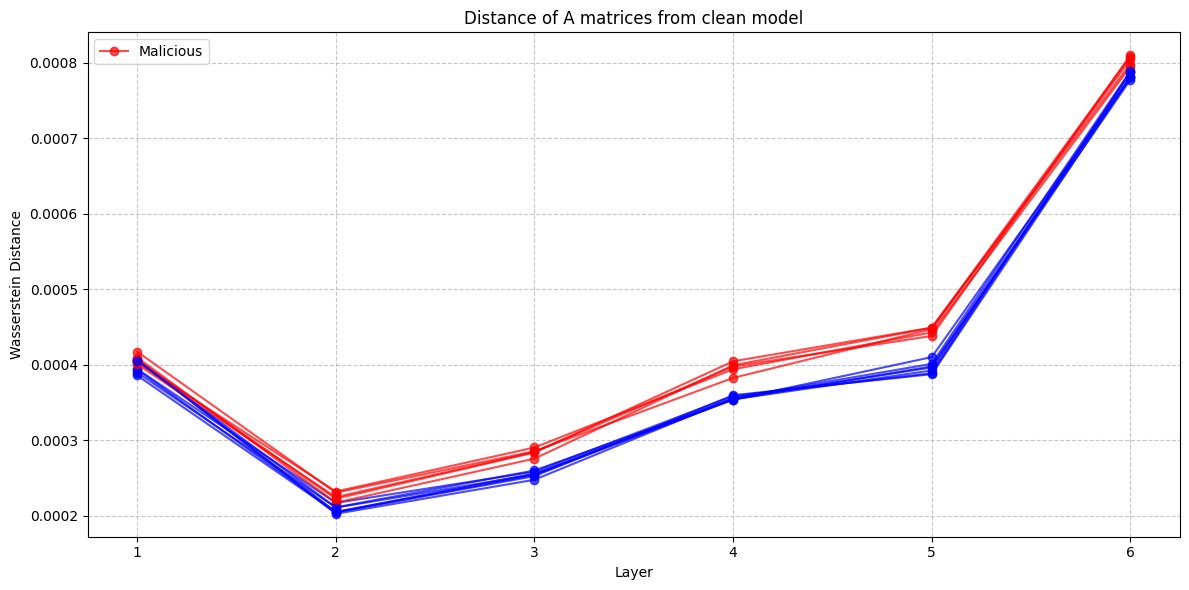

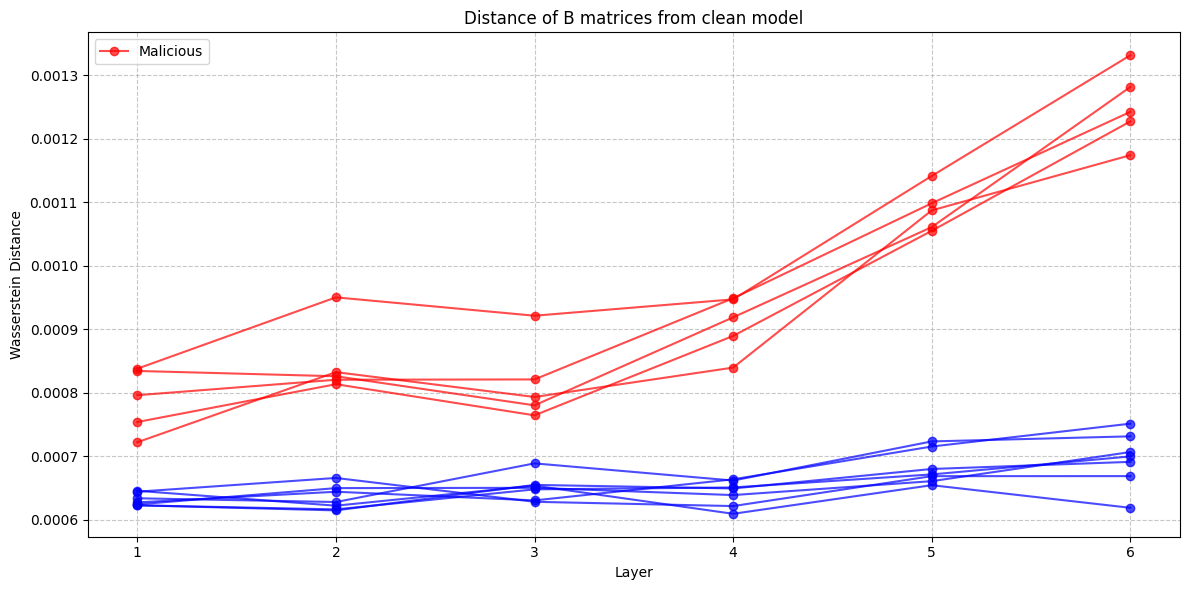

In [96]:
A_distances = compute_wa_distances(clean_A_matrices, client_A_matrics)
B_distances = compute_wa_distances(clean_B_matrices, client_B_matrics)

num_layers = 6
layers = np.arange(1, num_layers + 1)

# Create a figure for A matrices distances
plt.figure(figsize=(12, 6))
for i in range(len(A_distances['Layer_1'])):
    if i in BD_users:
        plt.plot(layers, [A_distances[f'Layer_{j}'][i] for j in layers], 'o-', color=color_map['malicious'], alpha=0.7, label='Malicious' if i == BD_users[0] else "")
    else:
        plt.plot(layers, [A_distances[f'Layer_{j}'][i] for j in layers], 'o-', color=color_map['benign'], alpha=0.7, label='Benign' if i == 0 else "")

plt.title('Distance of A matrices from clean model')
plt.xlabel('Layer')
plt.ylabel('Wasserstein Distance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Create a figure for B matrices distances
plt.figure(figsize=(12, 6))
for i in range(len(B_distances['Layer_1'])):
    if i in BD_users:
        plt.plot(layers, [B_distances[f'Layer_{j}'][i] for j in layers], 'o-', color=color_map['malicious'], alpha=0.7, label='Malicious' if i == BD_users[0] else "")
    else:
        plt.plot(layers, [B_distances[f'Layer_{j}'][i] for j in layers], 'o-', color=color_map['benign'], alpha=0.7, label='Benign' if i == 0 else "")

plt.title('Distance of B matrices from clean model')
plt.xlabel('Layer')
plt.ylabel('Wasserstein Distance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [97]:
from defense_utils import compute_weighted_distance_with_attention

layer_variances = {layer: np.var(B_distances[layer]) for layer in B_distances.keys()}

distance_with_attention = compute_weighted_distance_with_attention(B_distances, layer_variances)

In [98]:
def compute_amplified_weighted_distance(distances, layer_variances, beta=2.0):
    num_clients = len(distances[next(iter(distances))])
    weighted_distances = [0.0] * num_clients
    
    # Calculate attention weights based on variance
    attention_weights = {layer: np.exp(var) for layer, var in layer_variances.items()}
    attention_sum = sum(attention_weights.values())
    normalized_attention = {layer: weight / attention_sum for layer, weight in attention_weights.items()}
    
    # Calculate median and MAD for each layer
    medians = {}
    mads = {}
    for layer in distances:
        layer_distances = distances[layer]
        median_dist = np.median(layer_distances)
        deviations = [abs(d - median_dist) for d in layer_distances]
        mad = np.median(deviations)
        medians[layer] = median_dist
        mads[layer] = mad if mad > 1e-10 else 1e-10  # Prevent division by zero
    
    # Compute amplified weighted distances
    for layer, weight in normalized_attention.items():
        for i in range(num_clients):
            distance = distances[layer][i]
            # Calculate normalized deviation
            normalized_deviation = abs((distance - medians[layer]) / mads[layer])
            # Apply amplification factor
            amplification = 1 + weight * (normalized_deviation ** beta)
            # Add to weighted distance
            weighted_distances[i] += weight * distance * amplification
            
    return weighted_distances

In [31]:
distance_with_amplification = compute_amplified_weighted_distance(B_distances, layer_variances, beta=2.0)

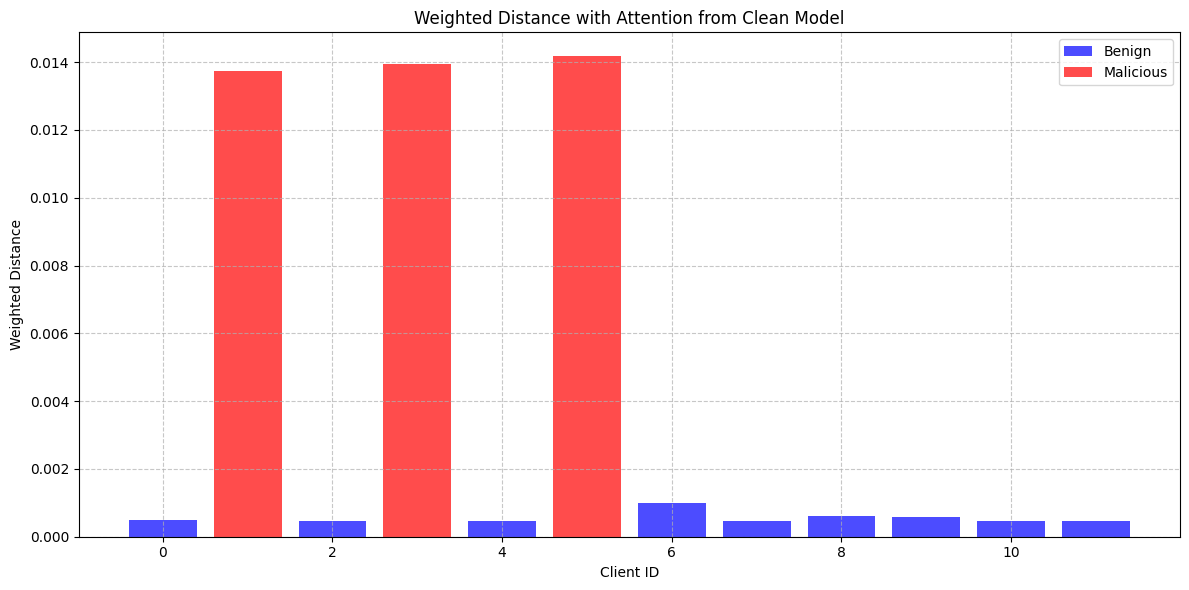

In [32]:
# Plot the distance with attention
plt.figure(figsize=(12, 6))
for i in range(len(distance_with_amplification)):
    if i in BD_users:
        plt.bar(i, distance_with_amplification[i], color=color_map['malicious'], alpha=0.7, label='Malicious' if i == BD_users[0] else "")
    else:
        plt.bar(i, distance_with_amplification[i], color=color_map['benign'], alpha=0.7, label='Benign' if i == 0 else "")

plt.title('Weighted Distance with Attention from Clean Model')
plt.xlabel('Client ID')
plt.ylabel('Weighted Distance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import silhouette_score
def calculate_robust_thresholds(weighted_distances, alpha=2.0):
    """
    Calculate robust thresholds using median and MAD for weighted distances.
    :param weighted_distances: List of weighted distances for each client.
    :param alpha: Scaling factor for threshold adjustment.
    :return: A dictionary containing 'upper' and 'lower' thresholds.
    """
    median = np.median(weighted_distances)
    mad = np.median(np.abs(weighted_distances - median))
    upper_threshold = median + alpha * mad
    lower_threshold = median - alpha * mad
    return {'upper': upper_threshold, 'lower': lower_threshold}

def calculate_mean_std_thresholds(weighted_distances, alpha=2.0):
    """
    Calculate thresholds using mean and standard deviation for weighted distances.
    :param weighted_distances: List of weighted distances for each client.
    :param alpha: Scaling factor for threshold adjustment.
    :return: A dictionary containing 'upper' and 'lower' thresholds.
    """
    mean = np.mean(weighted_distances)
    std_dev = np.std(weighted_distances)
    upper_threshold = mean + alpha * std_dev
    lower_threshold = mean - alpha * std_dev
    return {'upper': upper_threshold, 'lower': lower_threshold}

def detect_outliers_with_silhouette_simple(weighted_distances):
    # Reshape for sklearn compatibility
    distances_array = np.array(weighted_distances).reshape(-1, 1)
    
    # Try different percentile thresholds and find the one with best silhouette score
    best_score = -1
    best_threshold = None
    best_labels = None
    
    for percentile in range(60, 91, 5):  # Try 60%, 65%, 70%, ... 90%
        threshold = np.percentile(weighted_distances, percentile)
        labels = (distances_array > threshold).astype(int)
        
        # Only evaluate if we have both normal and outlier points
        if len(np.unique(labels)) > 1 and min(np.sum(labels == 0), np.sum(labels == 1)) >= 2:
            score = silhouette_score(distances_array, labels)
            if score > best_score:
                best_score = score
                best_threshold = threshold
                best_labels = labels
    
    # If we found a valid threshold
    if best_labels is not None:
        # Return indices of outlier clients (labeled as 1)
        outlier_indices = np.where(best_labels == 1)[0].tolist()
        return outlier_indices, best_score, best_threshold
    else:
        # Fallback to MAD-based threshold if no good clustering found
        med = np.median(weighted_distances)
        mad = np.median(np.abs(np.array(weighted_distances) - med))
        threshold = med + 2 * mad
        outlier_indices = [i for i, d in enumerate(weighted_distances) if d > threshold]
        return outlier_indices, -1, threshold

outlier_indices, best_score, best_threshold = detect_outliers_with_silhouette_simple(distance_with_attention)

robust_thresholds = calculate_robust_thresholds(distance_with_amplification, alpha=3.0)
mean_std_thresholds = calculate_mean_std_thresholds(distance_with_amplification, alpha=1.0)
print(f"Robust Upper Threshold: {robust_thresholds['upper']}")
print(f"Robust Lower Threshold: {robust_thresholds['lower']}")
print(f"Mean Std Upper Threshold: {mean_std_thresholds['upper']}")
print(f"Mean Std Lower Threshold: {mean_std_thresholds['lower']}")


Robust Upper Threshold: 0.0007240277968067367
Robust Lower Threshold: 0.00033325587606430885
Mean Std Upper Threshold: 0.009707059569533839
Mean Std Lower Threshold: -0.0018983156262408819


/Users/vblack/opt/miniconda3/envs/fedllm/lib/python3.8/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/vblack/opt/miniconda3/envs/fedllm/lib/python3.8/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/vblack/opt/miniconda3/envs/fedllm/lib/python3.8/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/vblack/opt/miniconda3/envs/fedllm/lib/python3.8/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning

In [36]:
outlier_indices

[1, 3, 5]

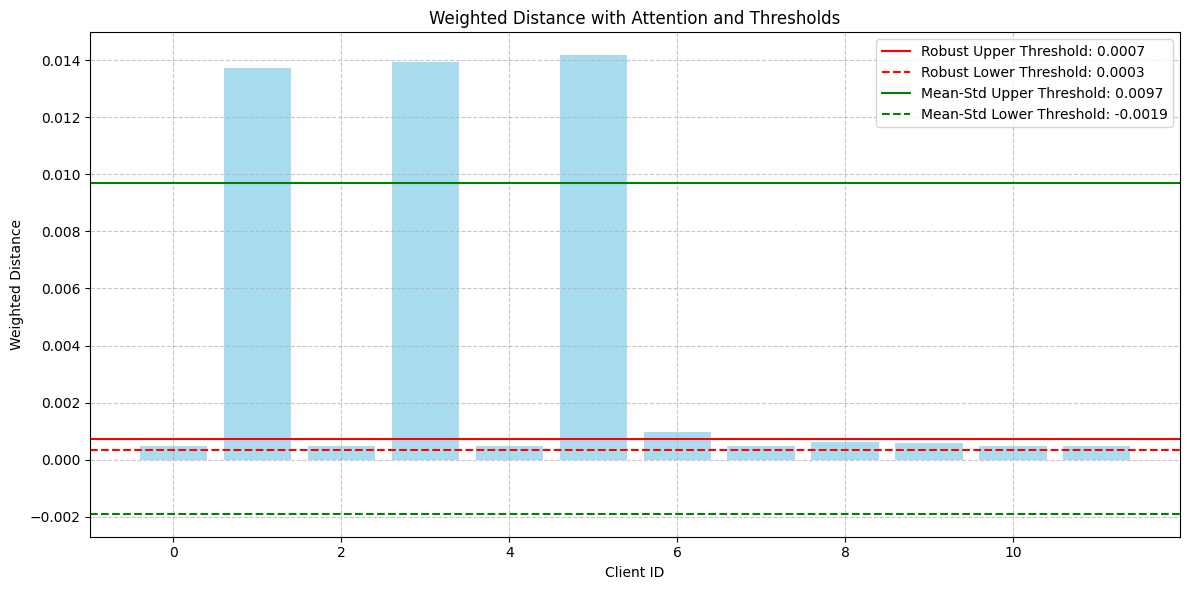

In [34]:
# Plot the weighted distances with thresholds
plt.figure(figsize=(12, 6))
plt.bar(range(len(distance_with_amplification)), distance_with_amplification, color='skyblue', alpha=0.7)

# Add horizontal lines for robust thresholds
plt.axhline(y=robust_thresholds['upper'], color='r', linestyle='-', label=f'Robust Upper Threshold: {robust_thresholds["upper"]:.4f}')
plt.axhline(y=robust_thresholds['lower'], color='r', linestyle='--', label=f'Robust Lower Threshold: {robust_thresholds["lower"]:.4f}')

# Add horizontal lines for mean-std thresholds
plt.axhline(y=mean_std_thresholds['upper'], color='g', linestyle='-', label=f'Mean-Std Upper Threshold: {mean_std_thresholds["upper"]:.4f}')
plt.axhline(y=mean_std_thresholds['lower'], color='g', linestyle='--', label=f'Mean-Std Lower Threshold: {mean_std_thresholds["lower"]:.4f}')

plt.title('Weighted Distance with Attention and Thresholds')
plt.xlabel('Client ID')
plt.ylabel('Weighted Distance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [82]:
weight_path = 'save/client_weights_distilbert'
epoch = 5
w = []
BD_users = []
for i in range(epoch):
    weight_path = f'save/client_weights_distilbert/epoch{i}.pkl'
    with open(weight_path, 'rb') as f:
        client_weights = pickle.load(f)
    weights = []
    is_poisoned = []
    for k, v in client_weights.items():
        weights.append(v['weights'])
        is_poisoned.append(v['is_poisoned'])
    w.append(weights)
    BD_users.append(is_poisoned)

/Users/vblack/opt/miniconda3/envs/fedllm/lib/python3.8/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


In [83]:
BD_users = np.array(BD_users)
is_poisoned = np.where(BD_users == True)
is_poisoned


(array([0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4]),
 array([ 0,  5,  7,  0,  8,  9,  1,  5,  7,  8,  9, 11,  0,  3,  4,  9,  1,
         2,  4,  7]))

In [84]:
poison_indices = []
for i in range(epoch):
    poison_indices.append(np.where(BD_users[i] == True)[0])
poison_indices

[array([0, 5, 7]),
 array([0, 8, 9]),
 array([ 1,  5,  7,  8,  9, 11]),
 array([0, 3, 4, 9]),
 array([1, 2, 4, 7])]

In [85]:
B_matrices = []
for i in range(epoch):
    _, B_mat = extract_lora_matrices(model_name=model_name, clients_state_dicts=w[i], num_layers=6)
    B_matrices.append(B_mat)

In [86]:
len(B_matrices[0]['Layer_1'])

12

In [87]:
B_distances = []
for i in range(epoch):
    B_distances.append(compute_wa_distances(clean_B_matrices, B_matrices[i]))

In [88]:
layer_variances = []
B_distances_with_attention = []
for i in range(epoch):
    layer_vars = {layer: np.var(B_distances[i][layer]) for layer in B_distances[i].keys()}
    layer_variances.append(layer_vars)
    distance_with_attention = compute_weighted_distance_with_attention(B_distances[i], layer_vars)
    B_distances_with_attention.append(distance_with_attention)

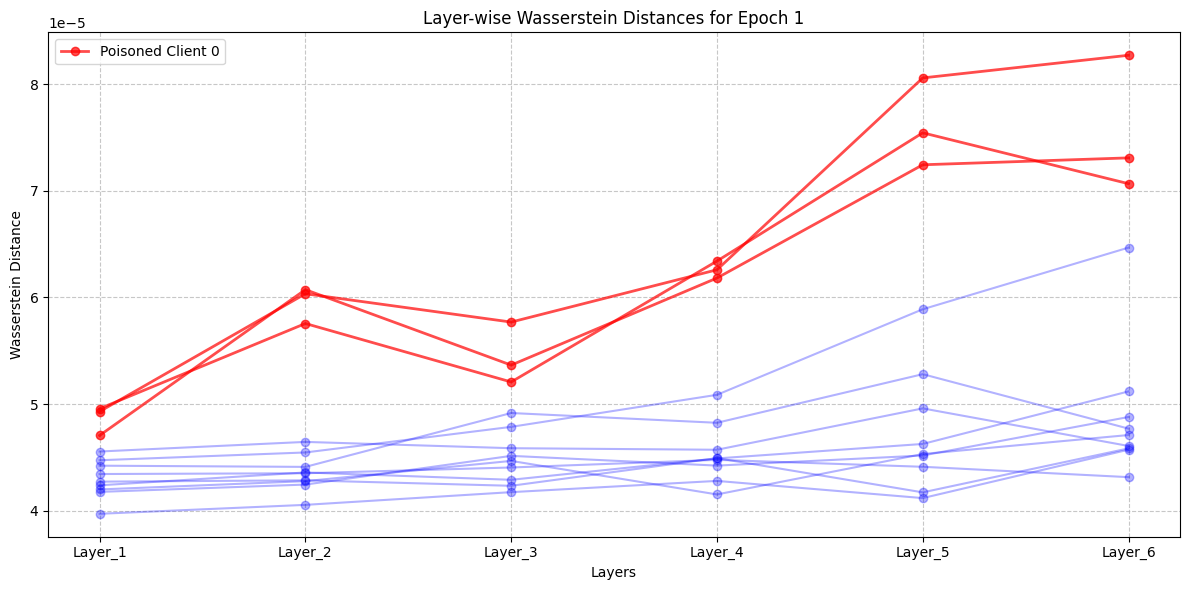

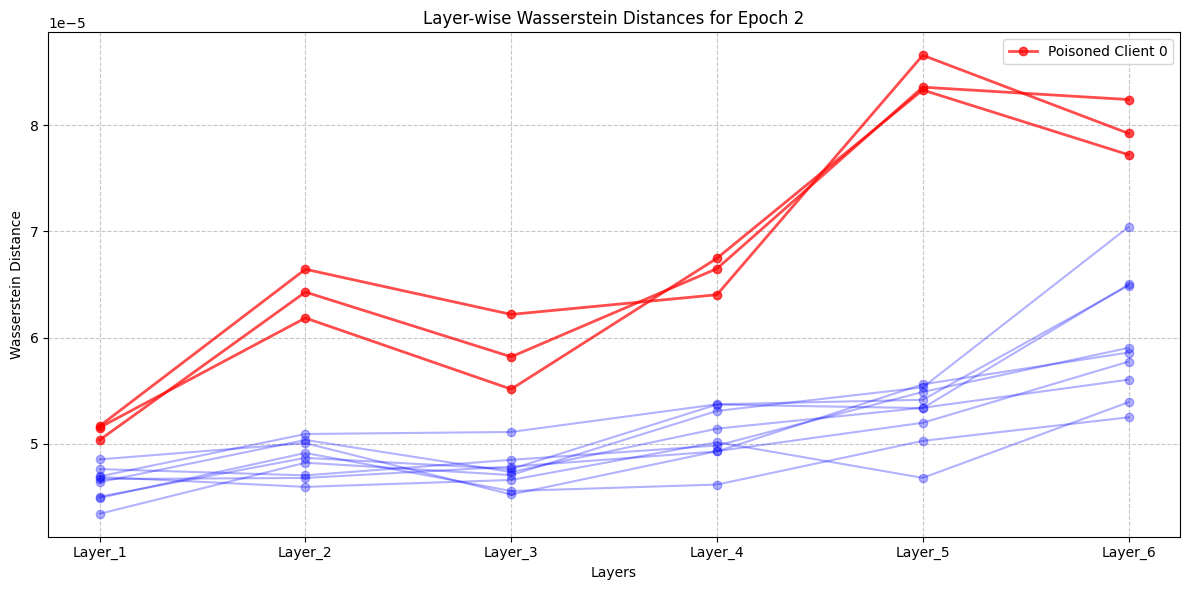

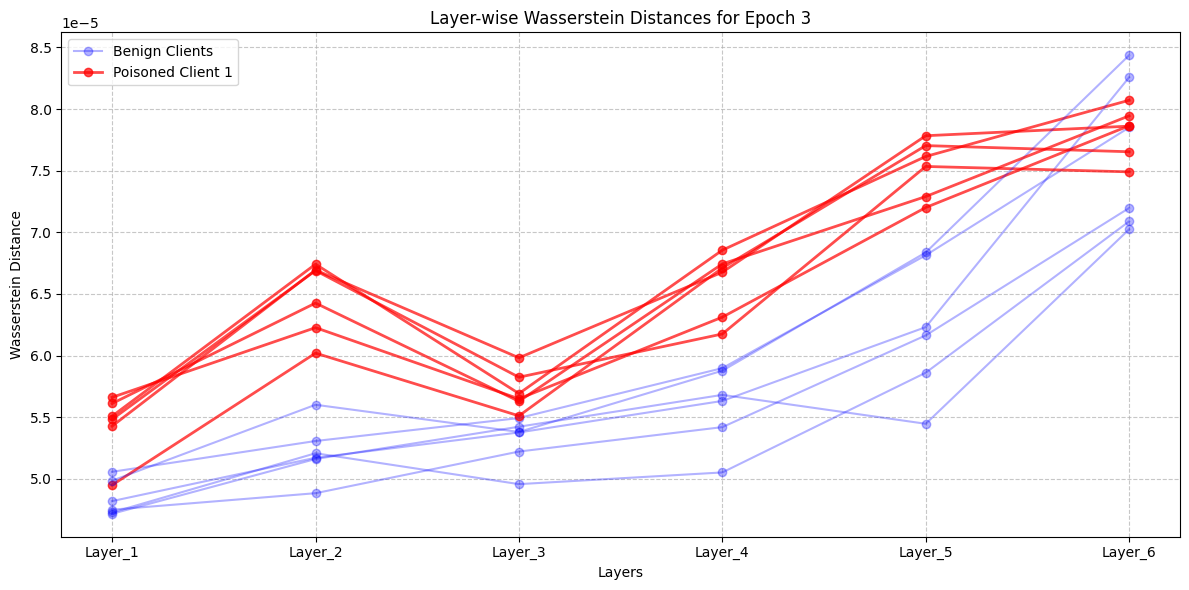

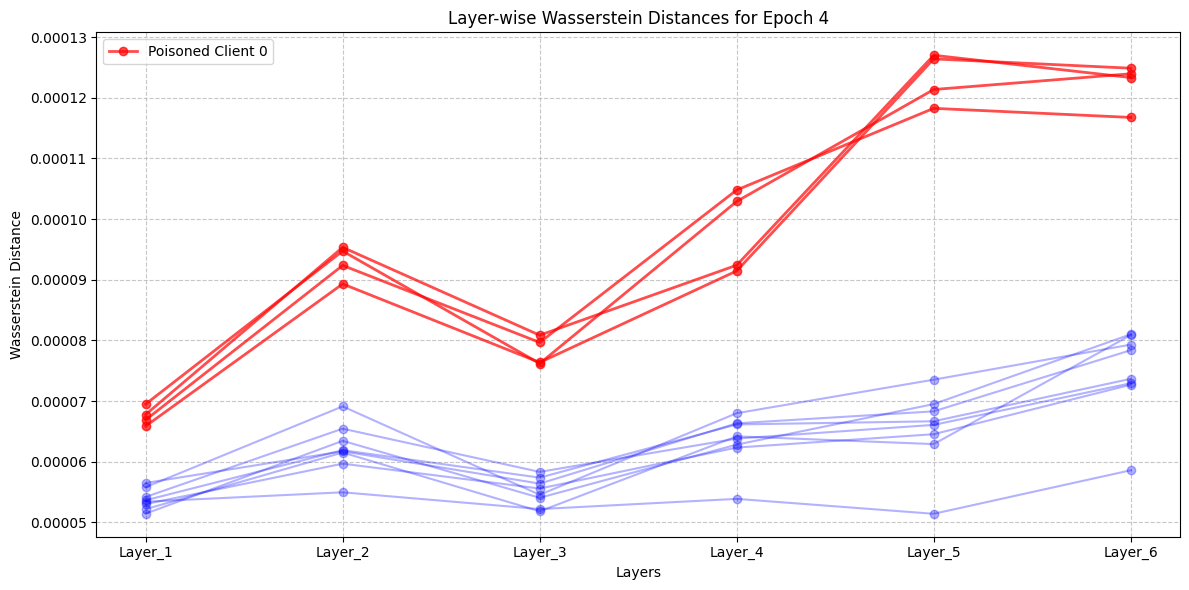

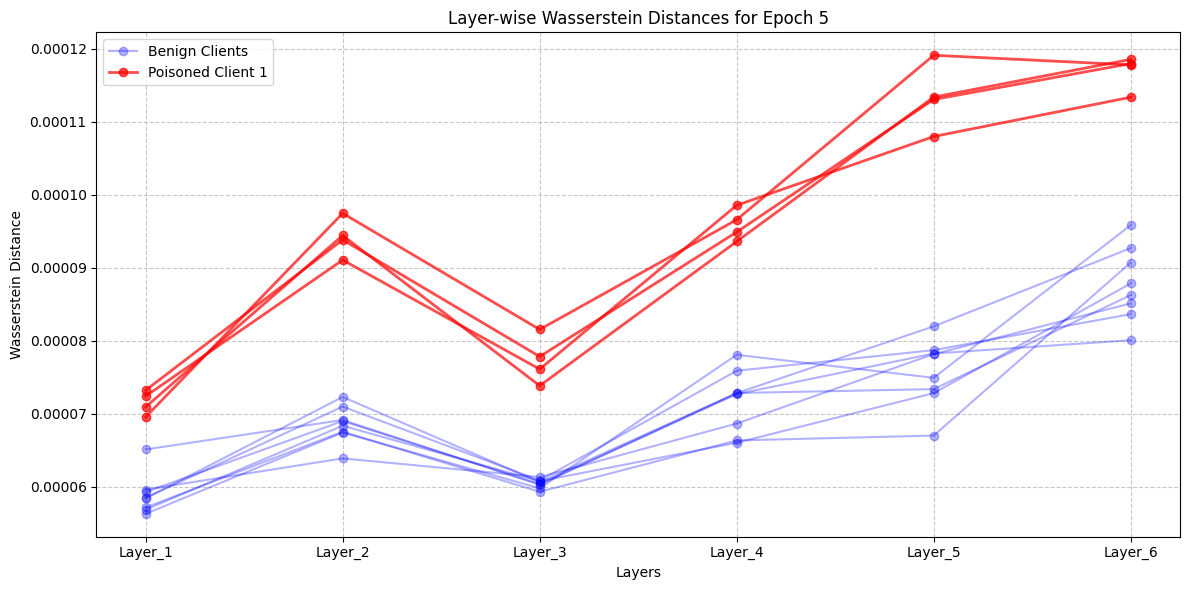

In [89]:
# Create a figure for each epoch
for epoch_idx in range(epoch):
    plt.figure(figsize=(12, 6))
    
    # Get distances for this epoch
    distances = B_distances[epoch_idx]
    
    # Get poisoned clients for this epoch
    poisoned_clients = poison_indices[epoch_idx]
    
    # Extract layer names and sort them
    layers = sorted(distances.keys())
    
    # For each client, plot their distances across layers
    for client_idx in range(len(distances[layers[0]])):
        # Extract distances for this client across all layers
        client_distances = [distances[layer][client_idx] for layer in layers]
        
        # Check if this client is poisoned
        is_poisoned = client_idx in poisoned_clients
        
        # Plot with different style based on whether client is poisoned
        if is_poisoned:
            plt.plot(layers, client_distances, 'ro-', alpha=0.7, linewidth=2, 
                     label=f'Poisoned Client {client_idx}' if client_idx == poisoned_clients[0] else None)
        else:
            plt.plot(layers, client_distances, 'bo-', alpha=0.3, 
                     label='Benign Clients' if client_idx == 0 else None)
    
    plt.xlabel('Layers')
    plt.ylabel('Wasserstein Distance')
    plt.title(f'Layer-wise Wasserstein Distances for Epoch {epoch_idx+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [90]:
# Compute distances with attention for each epoch
B_distances_with_attention_by_epoch = []

for epoch_idx in range(epoch):
    # Get distances for this epoch
    distances = B_distances[epoch_idx]
    
    # Get poisoned clients for this epoch
    poisoned_clients = poison_indices[epoch_idx]
    
    # Calculate layer variances for this epoch
    layer_vars = {layer: np.var(distances[layer]) for layer in distances.keys()}
    
    # Compute weighted distances with attention
    weighted_distances = compute_weighted_distance_with_attention(distances, layer_vars)
    
    # Store the weighted distances for this epoch
    B_distances_with_attention_by_epoch.append(weighted_distances)

# Print the weighted distances for each epoch
for epoch_idx in range(epoch):
    print(f"Epoch {epoch_idx+1} Weighted Distances:")
    weighted_distances = B_distances_with_attention_by_epoch[epoch_idx]
    
    # Mark poisoned clients
    for client_idx, distance in enumerate(weighted_distances):
        if client_idx in poison_indices[epoch_idx]:
            print(f"  Client {client_idx}: {distance:.6f} (POISONED)")
        else:
            print(f"  Client {client_idx}: {distance:.6f}")

Epoch 1 Weighted Distances:
  Client 0: 0.000061 (POISONED)
  Client 1: 0.000044
  Client 2: 0.000043
  Client 3: 0.000045
  Client 4: 0.000048
  Client 5: 0.000061 (POISONED)
  Client 6: 0.000047
  Client 7: 0.000066 (POISONED)
  Client 8: 0.000045
  Client 9: 0.000042
  Client 10: 0.000052
  Client 11: 0.000044
Epoch 2 Weighted Distances:
  Client 0: 0.000068 (POISONED)
  Client 1: 0.000051
  Client 2: 0.000054
  Client 3: 0.000053
  Client 4: 0.000052
  Client 5: 0.000051
  Client 6: 0.000050
  Client 7: 0.000048
  Client 8: 0.000066 (POISONED)
  Client 9: 0.000068 (POISONED)
  Client 10: 0.000048
  Client 11: 0.000051
Epoch 3 Weighted Distances:
  Client 0: 0.000055
  Client 1: 0.000067 (POISONED)
  Client 2: 0.000056
  Client 3: 0.000056
  Client 4: 0.000061
  Client 5: 0.000065 (POISONED)
  Client 6: 0.000059
  Client 7: 0.000065 (POISONED)
  Client 8: 0.000067 (POISONED)
  Client 9: 0.000064 (POISONED)
  Client 10: 0.000062
  Client 11: 0.000066 (POISONED)
Epoch 4 Weighted Dista

In [ ]:
# detect outliers with silhouette
outlier_indices_with_attention = []
for epoch_idx in range(epoch):
    weighted_distances = B_distances_with_attention_by_epoch[epoch_idx]
    outlier_indices, best_score, best_threshold = detect_outliers_with_silhouette_simple(weighted_distances)
    outlier_indices_with_attention.append(outlier_indices)

In [80]:
krum_scores = []
for i in range(epoch):
    krum_scores.append(krum(w[i], len(w[i])))
krum_scores


[[3], [11], [3], [6], [11]]

In [81]:
multi_krum_scores = []
for i in range(epoch):
    multi_krum_scores.append(multi_krum(w[i], len(w[i])))
multi_krum_scores

[array([ 3,  7,  1, 10,  9, 11,  4,  5]),
 array([11,  2,  9, 10,  6,  7,  0,  5]),
 array([ 3,  5, 11,  6, 10,  2,  0,  7]),
 array([ 6,  5,  7, 10,  1,  8, 11,  4]),
 array([11,  5,  1,  6,  3,  0,  4,  2])]